# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 1
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [3]:
fig_save_prefix = f"../results/2P/"

# Common Imports

In [4]:
from .common.cache import loadCachedOrRunNSave as ld
from .common.definitions import BrainRegion
import numpy as np
from tqdm.auto import tqdm
ACQ_RATE = 30 # TODO: Read dynamically

In [5]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignOriginalQuantile(df):
    df_li = []
    assert df.index.nunique() == len(df)
    len_before = len(df)
    df = df[df.calcStimulusTime.notnull()]
    # print(f"Dropping {len_before - len(df)} rows with null calcStimulusTime")
    org_df = df.copy()
    # Each trial has multiple epochs, drop them and keep only one row per trial
    df = df.drop_duplicates(subset=["Name", "Date", "SessionNum", "TrialNumber"])
    df = df.reset_index(drop=True)
    for quantile_idx, quantile_df in splitStimulusTimeByQuantile(df):
        quantile_df = quantile_df.copy()
        quantile_df["quantile_idx"] = quantile_idx
        df_li.append(quantile_df)
    df = pd.concat(df_li)
    # Assign back to original df
    org_df_li = []
    org_df["quantile_idx"] = -1
    for idx, row in df.iterrows():
        mask = (
            (org_df["Name"] == row["Name"]) &
            (org_df["Date"] == row["Date"]) &
            (org_df["SessionNum"] == row["SessionNum"]) &
            (org_df["TrialNumber"] == row["TrialNumber"])
        )
        temp_df = org_df[mask].copy()
        temp_df["quantile_idx"] = row["quantile_idx"]
        org_df_li.append(temp_df)
    reassigned_df = pd.concat(org_df_li)
    # reassigned_df = reassigned_df.sort_index()
    reassigned_df = reassigned_df.sort_values(["Name", "Date", "SessionNum", "TrialNumber", 
                                               "trace_start_idx", "state_id" ])
    reassigned_df = reassigned_df.reset_index(drop=True)
    return reassigned_df

# Load source data

In [7]:
_FP = "../data/2p/df_all_by_epoch_df_f_filtered.pkl"
import pickle
with open(_FP, "rb") as f:
  df_all_by_epoch = pickle.load(f)

In [8]:
from .pipeline import tracesnormalize
from .twop.alignsampling import alignSampling
import pandas as pd

normalization = tracesnormalize.NoNormalization()


TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_MOVEMENT = 0.1
NUM_QUANTILES = 3

_alignSamplingKargs = dict(normalization=normalization,#tracesnormalize.NormalizeZScore(set_name="neuronal"),
                           time_before_sampling=TIME_BEFORE_SAMPLING,
                           time_after_sampling=TIME_AFTER_MOVEMENT,)

In [9]:
%%capture
normed_sampling_df = alignSampling(df_all_by_epoch.copy(), normalize_epoch_time=True,
                                   **{k:v for k,v in _alignSamplingKargs.items() if k != 'normalization'},
                                   normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
                                   normalize_sessions_before_splitting=True
                                   )
normed_sampling_df["epoch"] = "Sampling"

In [25]:
df_all_by_trial_normalized = pd.read_pickle("../data/2p/df_all_by_trial_normalized.pkl")

# Common function to plot

In [11]:
common_kargs = dict(cached_df_avgs={}, 
                    cache_extra_prefix=f"normalized_sampling_{NUM_QUANTILES}_quantiles_align_{TIME_BEFORE_SAMPLING}s_before_sampling_{TIME_AFTER_MOVEMENT}s_after_movement")

In [ ]:
from .twop.plottracesavg import plotNormalized as plotNormalizedT, Combinations, Plots
from .twop.evd_conditions_common import SplitLevelBy
from functools import partial

def avg(df, cached_df_avgs, cache_extra_prefix, split_by_quantile,
        split_by_session,  combination : Combinations,
        # only_sgf : bool,
        resort_heatmaps : bool, resort_using_all : bool,
        only_common_sort_not_common_rng : bool,
        only_single_sess : bool, save_figs,
        sgf_data_col : str = None, sgf_prior_data_col : str = None,
        plot_traces : bool = False, only_sgf : bool = None,
        ):
    '''
    only_common_sort_not_common_rng : bool
        If False, the 0-1 of each row will be calculated across all generated
        heatmaps, not just relative to the current average row. I.e, when True,
        you are guaranteed that each row will go from 0 to 1.
    '''
    if resort_using_all:
        assert resort_heatmaps, (
            "Doesn't make sense to resort all without `resort_heatmaps = True`")

    if only_single_sess:
        assert split_by_session, ("Set `split_by_session = True`, otherwise "
        "session will be saved under the another folder with wrong session name")

    if only_sgf:
        assert sgf_data_col is not None, (
                           "If only_sgf is True, sgf_data_col must be provided")
    if sgf_data_col is not None:
        if only_sgf is None:
            only_sgf = True
        # with open("sgf_choice.pkl", "rb") as f:
        with open("sgf_all.pkl", "rb") as f:
            sgf_traces_df = pickle.load(f)
            sgf_traces_df = sgf_traces_df[sgf_traces_df.data_col == sgf_data_col]
            if sgf_prior_data_col is not None:
                sgf_traces_df = sgf_traces_df[sgf_traces_df.prior_data_col == sgf_prior_data_col]
            else:
                sgf_traces_df = sgf_traces_df[sgf_traces_df.prior_data_col.isnull()]
            sgf_traces_set = set(sgf_traces_df.long_trace_id)
            sgf_traces_set = {f"{_id.rsplit('_', 1)[1]}_{_id.rsplit('_', 1)[0]}"
            for _id in sgf_traces_set}
        print("sgf_traces_set:", sgf_traces_set)
    # combinations = [
    # # Combinations.All,
    # # Combinations.Evidence,
    # # Combinations.EvidenceDirection,
    # # Combinations.Direction,
    # # Combinations.PrevDirCurDir,
    # # Combinations.PrevDirection,
    # # Combinations.ChoiceCorrect,
    # # Combinations.ChoiceCorrectCurDir,
    # # Combinations.PrevChoiceCorrect,
    # # Combinations.PrevChoiceCurDir,
    # # Combinations.PrevChoicePrevDir,
    # # Combinations.PrevChoicePrevDirCurDirLeft,
    # # Combinations.SamplingTime,
    # # Combinations.Quantile,
    # # Combinations.QuantileDirection,
    # ]
    combinations = [combination]
    plots = [Plots.Heatmap] if not plot_traces else [Plots.Traces]
    def onlyTracesIds(set_name, traces_ids, group_info):
        # print("group info:", group_info)
        good_set = set()
        printed_once = False
        #q_idx = group_info["quantile_idx"]
        # q_sgf_set = sgf_set_by_idx_dict[q_idx]
        if set_name == "neuronal":
            for trace_id in traces_ids:
                if not printed_once:
                    # print("trace_id:", trace_id)
                    printed_once = True
                if not only_single_sess or (
                  any((key in trace_id for key in ("GP4_23_S1", "GP4_23_s8",
                                                   "gp4_81_S5")))):
                    # if sgf_data_col is None or trace_id in sgf_traces_set:#q_sgf_set:
                    if not only_sgf or trace_id in sgf_traces_set:
                        # print("Found match:", trace_id)
                        good_set.add(trace_id)
                    # else:
                    #    print("Not accepted...")
                    # good_set.add(trace_id)
        # print("good_set:", len(good_set), "- out of:", len(sgf_traces_set))
        return good_set

    def heatMapSortSrcDf(df, split_level, by_kws, match_cols):
        print("By split level:", split_level)
        print("Local Match cols:", match_cols)
        print("By kws:", by_kws)
        #   display(pd.DataFrame(df))
        #   display(df[0])
        if split_by_quantile:
            df = df[df.quantile_idx == 3]
        if "DVstr" in by_kws:
            df = df[df.DVstr == "Easy"]
        if "ChoiceCorrect" in by_kws:
            df = df[df.ChoiceCorrect == True]
        if "ChoiceLeft" in by_kws:
            df = df[df.ChoiceLeft == True]
        if "PrevChoiceLeft" in by_kws:
            df = df[df.PrevChoiceLeft == True]
        if "PrevChoiceCorrect" in by_kws:
            df = df[df.PrevChoiceCorrect == False]
        match_cols = [col for col in match_cols if col != "quantile_idx"]
        display(df)
        is_df_one_of_them = True
        return df, match_cols, split_level, is_df_one_of_them

    heatmap_sort_str = "" # Will be re-assigned below
    def renameSave(args):
        # display(args)
        dscrp = "" #combination.name
        # If it's combined, write it as the first thing
        is_comb_all_sess = not only_single_sess and not split_by_session
        if is_comb_all_sess:
            dscrp += "_all_sess"
        if split_by_quantile:
            dscrp += f"_q{args['quantile_idx']}"
        combination_kargs = combination.avg_kargs.copy()
        if combination_kargs.pop("by_difficulty", False):
            dscrp += f"_Diff{args['DVstr']}"
        if combination_kargs.pop("by_correctness", False):
            dscrp += "_Correct" if args["ChoiceCorrect"] else "_Incorrect"
        if combination_kargs.pop("by_direction", False):
            dscrp += "_Left" if args["ChoiceLeft"] else "_Right"
        if combination_kargs.pop("by_prev_direction", False):
            dscrp += "_PrevLeft" if args["PrevChoiceLeft"] else "_PrevRight"
        if combination_kargs.pop("by_prev_correct", False):
            dscrp += "_PrevIncorrect" if args["PrevChoiceCorrect"] else "_PrevCorrect"
        assert not len(combination_kargs), f"Unhandled kargs: {combination_kargs}"
        # if "Layer" in args:
        #     dscrp += f"_Layer_{args['Layer']}"
        # if only_sgf:
        if only_sgf and not plot_traces:
            dscrp += f"_only_sgf_{sgf_data_col}"
            if sgf_prior_data_col is not None:
                dscrp += f"_prior_{sgf_prior_data_col}"
        if not is_comb_all_sess:
            dscrp += f"_{args['ShortName']}"
        if "BrainRegion" in args and ~np.isnan(args['BrainRegion']):
            br_str = str(BrainRegion(args['BrainRegion']))
            br_str = br_str.split("_")[0]
            dscrp += f"_{br_str}"
        if not plot_traces:
            dscrp += f"_{heatmap_sort_str}"
            dscrp = dscrp[1:] # Remove first _
        return dscrp

    cur_split_level = SplitLevelBy.BrainRegion
    if split_by_quantile:
        cur_split_level |= SplitLevelBy.Quantile
    if split_by_session:
        cur_split_level |= SplitLevelBy.Session

    plotNormalized = partial(plotNormalizedT, save_figs_outliers=False,
                            fig_save_prefix=fig_save_prefix,
                            normalization=normalization,
                            split_level=cur_split_level,
                            align_feedback_time=None,
                            limit_end_epoch=True,
                            #normalize_by_session=normalize_by_session,
                            filter_outlier_trials=False)

    if resort_heatmaps:
        if resort_using_all:
            heatMapSortSrcDf = "None"
            heatmap_sort_str = "sorted_to_all"
        else:
            heatMapSortSrcDf = heatMapSortSrcDf
            heatmap_sort_str = "sorted_to"
            combination_kargs = combination.avg_kargs.copy()
            if split_by_quantile:
                heatmap_sort_str += "_q3"
            if combination_kargs.pop("by_difficulty", False):
                heatmap_sort_str += "_Easy"
            if combination_kargs.pop("by_correctness", False):
                heatmap_sort_str += "_Correct"
            if combination_kargs.pop("by_direction", False):
                heatmap_sort_str += "_Left"
            if combination_kargs.pop("by_prev_direction", False):
                heatmap_sort_str += "_PrevLeft"
            if combination_kargs.pop("by_prev_correct", False):
                heatmap_sort_str += "_PrevIncorrect"
            assert not len(combination_kargs), f"Unhandled kargs: {combination_kargs}"

        heatmap_sort_str += "_self_rng" if only_common_sort_not_common_rng else "_shared_rng"
    else:
        heatMapSortSrcDf = None
        heatmap_sort_str = "sorted_to_itself"

    plot_save_dir_prefix = ""
    plot_save_dir_prefix += "sgf/" if only_sgf else "sgf_and_not_sgf/"
    plot_save_dir_prefix += "quantiles/" if split_by_quantile else "no_quantiles/"
    plotNormalized(df_concat_norm=df, df_concat_without_feedback=None,
                    combinations=combinations, cached_df_avgs=cached_df_avgs,
                    plots=plots,
                    save_figs=save_figs,
                    plots_kargs={Plots.Heatmap:dict(plot_y_ids=True,
                                                    dpi=300,
                                                    heatMapSortSrcDf=heatMapSortSrcDf,
                                                    renameSaveFn=renameSave,
                                                    save_ext="svg",
                                                    only_common_sort_not_common_rng=only_common_sort_not_common_rng,
                                                    ),
                                  Plots.Traces:dict(sem_traces=True,
                                                    appendSaveFn=renameSave,
                                                    save_dir_prefix=plot_save_dir_prefix,
                                                    save_ext="svg",)
                                },
                    only_traces_ids=[], #["GP4_23_s8_L50_D250_ALM126"],
                    onlyTraceIdsPlotProcessFn=onlyTracesIds,
                    cache_extra_prefix=cache_extra_prefix,
                    save_context=(["quantile_idx"] if split_by_quantile else []) + \
                                 (["Layer", "BrainRegion", "ChoiceLeft"] if not plot_traces else [])
    )

# Heatmap common combinations

In [20]:
def loopCombinations(df, split_by_quantile, save_figs,
                     one_sample_plot=False):
    if one_sample_plot:
        assert not save_figs, "Probably not what you want"
    for sgf_data_col, sgf_prior_data_col in [(None, None),
                                             #("ChoiceLeft", None),
                                            ]:
        for combin_all_sess in [
                                #True,
                                False,
                                ]:
            for resort_to_another, another_is_all in [#(False, False), # Resort to itself
                                                      #(True, False), # Resort to another condition
                                                      (True, True), # Resort to all
                                                    ]:
                for only_common_sort_not_common_rng in [False,
                                                        True
                                                        ]:
                    for combination in [Combinations.All,
                                        #Combinations.Direction,
                                        #Combinations.ChoiceCorrect,
                                        #Combinations.PrevDirection,
                                        #Combinations.PrevChoiceCorrect,
                                        ]:
                        # Processing: combination.name = 'All' - combin_all_sess = True - resort_to_another = True -
                        # another_is_all = True - only_common_sort_not_common_rng = False - only_sgf = False - split_by_quantile = True
                        print(f"*****Processing: {combination.name = } - {combin_all_sess = } - {resort_to_another = } - {another_is_all = } - "
                              f"{only_common_sort_not_common_rng = } - {sgf_data_col = } - {sgf_prior_data_col = } {split_by_quantile = }")
                        avg(df=df, split_by_quantile=split_by_quantile, **common_kargs, combination=combination,
                            resort_heatmaps=resort_to_another, resort_using_all=another_is_all,
                            only_common_sort_not_common_rng=only_common_sort_not_common_rng,
                            **(dict(split_by_session=False, only_single_sess=False) if combin_all_sess else dict(split_by_session=True, only_single_sess=one_sample_plot)),
                            sgf_data_col=sgf_data_col, sgf_prior_data_col=sgf_prior_data_col,save_figs=save_figs)

*****Processing: combination.name = 'All' - combin_all_sess = False - resort_to_another = True - another_is_all = True - only_common_sort_not_common_rng = False - sgf_data_col = None - sgf_prior_data_col = None split_by_quantile = False
normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Processing All
Cache key: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
1. len(df): 23
2. len(df): 23
Cache key: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
1. len(df): 23
2. len(df): 23
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRe

  0%|          | 0/23 [00:00<?, ?it/s]

Match cols: ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
New match cols: ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe
Only ids: ['20_GP4_23_s3_L50_D250_M2', '51_GP4_85_s2_L100_D250_mm2', '354_GP4_23_s6_L50_D250_ALM', '108_GP4_23_S1_L50_D250_mm2', '16_GP4_28_S5_L40_D250_M2L', '9_GP4_28_S2_L51_D250_M2L', '231_GP4_23_s8_L50_D250_ALM', '102_GP4_23_s8_L50_D250_ALM', '11_GP4_85_s10_L70_D250_ALM', '16_GP4_28_S4_L40_D250_M2L', '137_GP4_23_s6_L50_D250_ALM', '130_GP4_85_s7_L70_D250_ALM', '188_GP4_85_s3_L70_D250_mm2', '25_GP4_23_s3_L50_D250_M2', '19_GP4_85_s3_L70_D250_mm2', '23_GP4_24_s4_L85_D250_M2', '31_GP4_28_S6_L40_D250_M2L', '39_GP4_23_s7_L50_D250_ALM', '34_GP4_28_S2_L51_D250_M2L', '38_gp4_81_S5_L50_D250_ALM', '6_GP4_85_S1_L70_D250_mm2', '60_GP4_85_s10_L70_D250_ALM', '25_gp4_81_S8_L65_D250_ALM', '107_GP4_23_s3_L50_D250_M2', '34_GP4_23_s7_L50_D250_ALM', '5_GP4_85_s2_L100_D250_mm2', '25_GP4_85_s3_L70_D250_mm2', '12_GP4_85_s6_L65_D250_ALM', '4_GP4_85_s7_L70_D250_ALM', '0_GP4_23_s7_L50_D250_ALM', '8_gp4_81_S8_L65_D250_ALM', '319_GP4_23_S1_L50_D250_mm

...

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['epoch']


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Plotting traces data as heatmap


  0%|          | 0/23 [00:00<?, ?it/s]

TypeError: TracesHeatMap._defaultSavePrefix() got an unexpected keyword argument 'save_context'

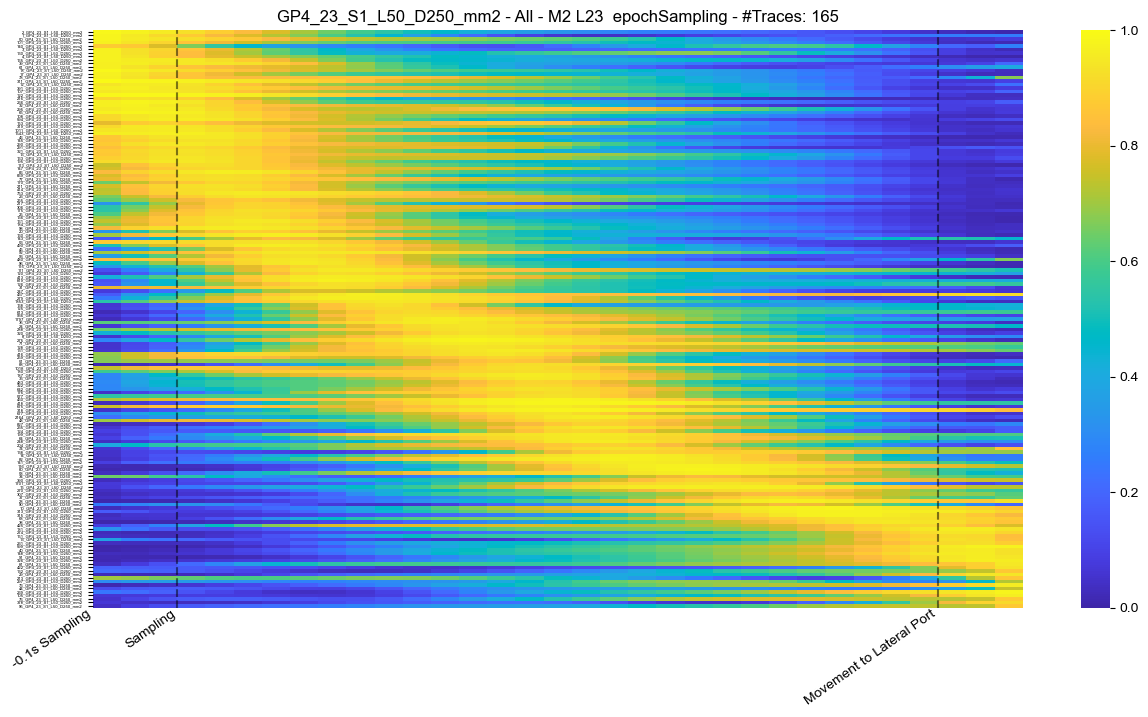

In [21]:
# Create first a common All-one without breaking it to quantiles
loopCombinations(normed_sampling_df, split_by_quantile=False, save_figs=True,
                 one_sample_plot=False)


In [23]:
normed_sampling_quantiles_df = assignOriginalQuantile(normed_sampling_df)

,Name,SessionNum,TrialNumber,ChoiceLeft
1,GP4-23,2,42,1.0
4,GP4-23,2,43,0.0
7,GP4-23,2,44,0.0
10,GP4-23,2,45,0.0
13,GP4-23,2,46,0.0
16,GP4-23,2,47,1.0
19,GP4-23,2,48,1.0
22,GP4-23,2,49,1.0
25,GP4-23,2,50,0.0
28,GP4-23,2,51,0.0


  0%|          | 0/23 [00:00<?, ?it/s]

,Name,SessionNum,TrialNumber,ChoiceLeft,quantile_idx
1,GP4-23,2,42,1.0,3
4,GP4-23,2,43,0.0,2
7,GP4-23,2,44,0.0,2
10,GP4-23,2,45,0.0,1
13,GP4-23,2,46,0.0,2
16,GP4-23,2,47,1.0,3
19,GP4-23,2,48,1.0,2
22,GP4-23,2,49,1.0,1
25,GP4-23,2,50,0.0,2
28,GP4-23,2,51,0.0,1


In [ ]:
loopCombinations(normed_sampling_quantiles_df, split_by_quantile=True, save_figs=True,
                 one_sample_plot=False)

*****Processing: combination.name = 'All' - combin_all_sess = False - resort_to_another = True - another_is_all = True - only_common_sort_not_common_rng = False - sgf_data_col = None - sgf_prior_data_col = None split_by_quantile = True
normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split5
normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split261
Processing All
Cache key: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split261
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split261
1. len(df): 69
2. len(df): 69
Cache key: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split5
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movementanalysis/ver2/2P_All_split5
1. len(df): 23
2. len(d

  0%|          | 0/69 [00:00<?, ?it/s]

Match cols: ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer', 'quantile_idx']
New match cols: ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe
Only ids: ['56_GP4_28_S1_L41_D250_M2L', '244_GP4_23_s3_L50_D250_M2', '28_GP4_28_S5_L40_D250_M2L', '12_GP4_80_S2_L51_D250_M2m', '114_GP4_24_s4_L85_D250_M2', '196_GP4_85_s7_L70_D250_ALM', '34_GP4_85_s6_L65_D250_ALM', '2_gp4_81_S5_L50_D250_ALM', '391_GP4_23_S1_L50_D250_mm2', '56_GP4_28_S4_L40_D250_M2L', '33_GP4_23_s6_L50_D250_ALM', '7_GP4_23_s8_L50_D250_ALM', '259_GP4_28_S5_L40_D250_M2L', '117_GP4_28_S6_L40_D250_M2L', '11_GP4_85_s10_L70_D250_ALM', '21_gp4_81_S8_L65_D250_ALM', '10_GP4_85_S1_L70_D250_mm2', '107_GP4_23_s3_L50_D250_M2', '148_GP4_23_s6_L50_D250_ALM', '11_GP4_28_S4_L40_D250_M2L', '262_GP4_23_s3_L50_D250_M2', '101_GP4_23_s7_L50_D250_ALM', '13_GP4_28_S2_L51_D250_M2L', '71_GP4_23_S1_L50_D250_mm2', '10_gp4_81_S5_L50_D250_ALM', '869_GP4_23_S1_L50_D250_mm2', '313_GP4_23_S1_L50_D250_mm2', '61_GP4_23_S1_L50_D250_mm2', '34_GP4_23_S1_L50_D250_mm2', '112_GP4_28_S2_L51_D250_M2L', '35_GP4_85_s6_L65_D250_ALM', '27_GP4_85_s9_L70_D2

...

  0%|          | 0/69 [00:00<?, ?it/s]

Processing: Smoothing traces with gaussian filter with sigma: 2


  0%|          | 0/69 [00:00<?, ?it/s]

Processing: Plotting traces data as heatmap


  0%|          | 0/69 [00:00<?, ?it/s]

# Plot average traces for different combinations

In [39]:
def loopCombinationsTraces(df, split_by_quantile, only_sgf, save_figs):
    local_kargs = common_kargs.copy()
    local_kargs.update(dict(resort_heatmaps=False, resort_using_all=False,
                            only_common_sort_not_common_rng=False, plot_traces=True,
                            split_by_session=True, only_single_sess=False
                            ))
    for combination, sgf_data_col, sgf_prior_data_col in [#(Combinations.All, None, None),
                                                          (Combinations.Direction, "ChoiceLeft", None),
                                                          #(Combinations.ChoiceCorrect, "ChoiceCorrect", None),
                                                          #(Combinations.Evidence, "IsEasy", None),
                                                          #(Combinations.PrevDirection, "PrevChoiceLeft", None),
                                                          #(Combinations.PrevChoiceCorrect, "PrevChoiceCorrect", None),
                                                        ]:
        # Processing: combination.name = 'All' - combin_all_sess = True - resort_to_another = True -
        # another_is_all = True - only_common_sort_not_common_rng = False - only_sgf = False - split_by_quantile = True
        print(f"*****Processing: {combination.name = } -  - "
              f" {sgf_data_col = } - {sgf_prior_data_col = } {split_by_quantile = }")
        avg(df=df, split_by_quantile=split_by_quantile, **local_kargs, combination=combination,
            sgf_data_col=sgf_data_col, sgf_prior_data_col=sgf_prior_data_col, save_figs=save_figs,
            only_sgf=only_sgf)

In [58]:
loopCombinationsTraces(normed_sampling_quantiles_df,  only_sgf=False,
                       split_by_quantile=False, save_figs=True)

*****Processing: combination.name = 'Direction' -  -  sgf_data_col = 'ChoiceLeft' - sgf_prior_data_col = None split_by_quantile = True
sgf_traces_set: {'17_GP4_85_s6_L65_D250_ALM', '83_GP4_23_s7_L50_D250_ALM', '25_GP4_85_s10_L70_D250_ALM', '7_GP4_23_s8_L50_D250_ALM', '21_gp4_81_S8_L65_D250_ALM', '48_GP4_23_S1_L50_D250_mm2', '13_GP4_23_s7_L50_D250_ALM', '180_GP4_23_s3_L50_D250_M2', '54_GP4_23_s8_L50_D250_ALM', '0_GP4_85_s2_L100_D250_mm2', '41_GP4_23_s8_L50_D250_ALM', '98_GP4_85_s7_L70_D250_ALM', '1797_GP4_23_S1_L50_D250_mm2', '23_gp4_81_S5_L50_D250_ALM', '75_GP4_85_s9_L70_D250_ALM', '483_GP4_23_S1_L50_D250_mm2', '82_GP4_85_s6_L65_D250_ALM', '9_GP4_28_S6_L40_D250_M2L', '70_GP4_28_S1_L41_D250_M2L', '115_GP4_85_s3_L70_D250_mm2', '262_GP4_23_s3_L50_D250_M2', '99_GP4_28_S6_L40_D250_M2L', '29_GP4_85_s10_L70_D250_ALM', '40_gp4_81_S8_L65_D250_ALM', '211_GP4_23_S1_L50_D250_mm2', '67_GP4_23_s8_L50_D250_ALM', '61_GP4_23_s8_L50_D250_ALM', '128_GP4_23_S1_L50_D250_mm2', '65_GP4_28_S1_L41_D250_M2L', '

  0%|          | 0/69 [00:00<?, ?it/s]

Iterating traces:   0%|          | 0/165 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/165 [00:00<?, ?it/s]

...

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/38 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/38 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


In [59]:
loopCombinationsTraces(normed_sampling_quantiles_df,  only_sgf=False,
                       split_by_quantile=False, save_figs=True)

*****Processing: combination.name = 'Direction' -  -  sgf_data_col = 'ChoiceLeft' - sgf_prior_data_col = None split_by_quantile = False
sgf_traces_set: {'17_GP4_85_s6_L65_D250_ALM', '83_GP4_23_s7_L50_D250_ALM', '25_GP4_85_s10_L70_D250_ALM', '7_GP4_23_s8_L50_D250_ALM', '21_gp4_81_S8_L65_D250_ALM', '48_GP4_23_S1_L50_D250_mm2', '13_GP4_23_s7_L50_D250_ALM', '180_GP4_23_s3_L50_D250_M2', '54_GP4_23_s8_L50_D250_ALM', '0_GP4_85_s2_L100_D250_mm2', '41_GP4_23_s8_L50_D250_ALM', '98_GP4_85_s7_L70_D250_ALM', '1797_GP4_23_S1_L50_D250_mm2', '23_gp4_81_S5_L50_D250_ALM', '75_GP4_85_s9_L70_D250_ALM', '483_GP4_23_S1_L50_D250_mm2', '82_GP4_85_s6_L65_D250_ALM', '9_GP4_28_S6_L40_D250_M2L', '70_GP4_28_S1_L41_D250_M2L', '115_GP4_85_s3_L70_D250_mm2', '262_GP4_23_s3_L50_D250_M2', '99_GP4_28_S6_L40_D250_M2L', '29_GP4_85_s10_L70_D250_ALM', '40_gp4_81_S8_L65_D250_ALM', '211_GP4_23_S1_L50_D250_mm2', '67_GP4_23_s8_L50_D250_ALM', '61_GP4_23_s8_L50_D250_ALM', '128_GP4_23_S1_L50_D250_mm2', '65_GP4_28_S1_L41_D250_M2L', 

  0%|          | 0/23 [00:00<?, ?it/s]

Iterating traces:   0%|          | 0/165 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/122 [00:00<?, ?it/s]

...

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/62 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


Iterating traces:   0%|          | 0/38 [00:00<?, ?it/s]

x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33
x-rng: x_trace[0] = 1, x_trace[-1] = 33


# Plot traces

In [12]:
align_feedback_time = 0.5 # sec
limit_end_epoch = True
feedback_common_kwargs = dict(cached_df_avgs={}, cache_extra_prefix=
                              f"feedback_normalized_align_feedback_{align_feedback_time}s_limit_end_{limit_end_epoch}")

In [13]:
_combin_all_sess = False
avg(df=df_all_by_trial_normalized,
    plot_traces=False,
    split_by_quantile=False, **feedback_common_kwargs, combination=Combinations.All,
    resort_heatmaps=True, resort_using_all=True,
    only_common_sort_not_common_rng=False,
    **(dict(split_by_session=False, only_single_sess=False) if _combin_all_sess else dict(split_by_session=True, only_single_sess=False)),
    save_figs=False)

NameError: name 'avg' is not defined

In [ ]:
_combin_all_sess = False
avg(df=df_all_by_trial_normalized,
    plot_traces=True,
    split_by_quantile=False, **feedback_common_kwargs, combination=Combinations.PrevChoiceCurDir,
    resort_heatmaps=False, resort_using_all=False,
    only_common_sort_not_common_rng=False,
    **(dict(split_by_session=False, only_single_sess=False) if _combin_all_sess else dict(split_by_session=True, only_single_sess=True)),
    #sgf_data_col=False, sgf_prior_data_col=False, 
    # only_traces_ids=["20_GP4_23_s1_L50_D250_mm2"],
    save_figs=False)

TypeError: avg() got an unexpected keyword argument 'only_traces_ids'